In [417]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import h5py
import matplotlib

In [418]:
from __future__ import division
import numpy as np
import bacco
import copy
import os
from bacco.halo import virial_mass_converter, virial_concentration_converter
from scipy import interpolate

bacco.configuration.update({'growth':{'method': 'reps'}})

In [419]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [420]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [421]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

#### Load the selection

In [422]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selection/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [423]:
mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

#### Load the simulations

In [424]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = ( mtng.fof['halo_pos'][:,0] - 125 ) % 500

2024-11-14 17:46:59,525 bacco.sims : Initialising simulation Default
2024-11-14 17:46:59,526 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-14 17:46:59,570 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-14 17:46:59,587 bacco.sims : ...done in 0.0619 s
2024-11-14 17:46:59,615 bacco.sims : Reading 98233510 items for GroupPos


In [425]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

name_list = ['fiducial', 'LH_2', 'LH_4', 'LH_8', 'LH_12', 'LH_13', 'LH_14', 'LH_17', 'LH_18', 'LH_19', 'LH_20', 'LH_21', 'LH_22', 'LH_23', 'LH_24']

for i in range(len(name_list)):

    base = "/cosmos_storage/data_sharing/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True)

print(zoom['LH_2'].header['Redshift'])

2024-11-14 17:47:52,898 bacco.sims : Initialising simulation Default
2024-11-14 17:47:52,899 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-11-14 17:47:52,936 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-11-14 17:47:52,953 bacco.sims : ...done in 0.055 s
2024-11-14 17:47:52,957 bacco.sims : Initialising simulation Default
2024-11-14 17:47:52,961 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2024-11-14 17:47:53,039 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2024-11-14 17:47:53,064 bacco.sims : ...done in 0.107 s
2024-11-14 17:47:53,065 bacco.sims : Initialising simulation Default
2024-11-14 17:47:53,065 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/LH_4/hydro_output/snapdir_264/snapshot_264
2024-11-14 17:47:53,124 bacco.sims : Loading 

4.440892098500626e-16


In [427]:
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264)

2024-11-14 17:51:47,616 bacco.sims : Initialising simulation Default
2024-11-14 17:51:47,617 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-14 17:51:47,618 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-11-14 17:51:47,624 bacco.sims : ...done in 0.00805 s
2024-11-14 17:51:47,629 bacco.sims : Reading 98233510 items for GroupPos
2024-11-14 17:51:52,187 bacco.sims : Reading 90246895 items for SubhaloPos
2024-11-14 17:52:40,542 bacco.sims : Reading 139825 items for GroupPos
2024-11-14 17:52:40,840 bacco.sims : Reading 139825 items for Group_M_Mean200
2024-11-14 17:52:40,903 bacco.sims : Reading 98233510 items for Group_M_Mean200
2024-11-14 17:53:15,613 bacco.sims : Reading 74741 items for SubhaloVmax
2024-11-14 17:53:15,853 bacco.sims : Reading 139825 items for halo_firstsub
2024-11-14 17:53:15,914 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-11-14 17:54:03,494 bacco.sims : Reading 98233510 ite

In [440]:
h_frac

array([5.85720143e-05, 5.80181016e-05, 5.81462961e-05, 5.87785811e-05,
       5.86957798e-05, 5.92768228e-05, 5.92417062e-05, 6.01503759e-05,
       6.03281853e-05, 6.07164542e-05, 6.03500302e-05, 6.08272506e-05,
       6.14024315e-05, 6.10090904e-05, 6.13760511e-05, 6.28180162e-05,
       6.24804749e-05, 6.21967906e-05, 6.32351081e-05, 6.40614990e-05,
       6.39836202e-05, 6.35364381e-05, 6.37551801e-05, 6.50364204e-05,
       6.55952771e-05, 6.55179192e-05, 6.58935161e-05, 6.64893617e-05,
       6.63525977e-05, 6.70645832e-05, 6.68136567e-05, 6.66045025e-05,
       6.75401864e-05, 6.79855871e-05, 6.83060109e-05, 6.83526999e-05,
       6.87805214e-05, 6.86860361e-05, 7.02099277e-05, 7.12809181e-05,
       7.04175762e-05, 7.15819613e-05, 7.21552782e-05, 7.16024631e-05,
       7.17257208e-05, 7.18184430e-05, 7.36865375e-05, 7.26269155e-05,
       7.30406837e-05, 7.40082889e-05, 7.30940721e-05, 7.33030347e-05,
       7.54375377e-05, 7.50807118e-05, 7.57346259e-05, 7.58207597e-05,
      

In [439]:
xmatch['fiducial']['ind']

array([ 4056,  4456,  4949,  3970,  4872,  4537,  6050,  4529,  3418,
        4494, 85670,  3659,  3931,  3670,  4549,  3975,  2547,  5021,
        4102,  4114,  4070,  4188,  3544,  6329, 35633,  4205,  3917,
        4231,  4078,  3430,  4303,  4461,  4428,  3784,  3054,  3534,
        3961,  3948,  3806,  3648,  2192,  4092,  2322,  6368,  3571,
        3265,  3681,  3484,  3231,  3273,  3518,  2789,  3329,  3630,
        3639,  3574,  2960,  3222,  3490,  3807,  3384,  3442,  2965,
        3216,  4356,  3306,  3629,  4190,  2719,  2427,  2982,  2811,
        3324,  3093,  3414,  4087,  3312,  3439,  2854,  2706,  3046,
        2890,  3291,  3006,  2662,  2634,  2840,  2775,  2851,  2772,
        3398,  2590,  2841,  3737,  2833,  2630,  3248,  2637,  3052,
        1904,  2632,  2745,  2437,  2535,  3139,  1724,  2353,  2693,
        2991,  2961,  2431,  2470,  2601,  2461,  3043,  2275,  2400,
        2552,  2767,  2349,  2194,  2677,  1700,  2544,  2553,  2643,
        2528,  2399,

In [428]:
m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

2024-11-14 18:00:55,499 bacco.sims : Reading 98233510 items for Group_M_Mean200
/tmp/ipykernel_365722/1893490096.py:1: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


#### Get the total SMF

In [429]:
mtng_split = utils.split_halos(mtng)
mtng_split.halo_sel_setup()

Nbins = 20

smf_total = mtng_split.total_smf(nbins=Nbins)

2024-11-14 18:03:07,181 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-11-14 18:03:08,899 bacco.sims : Reading 98233510 items for halo_firstsub
2024-11-14 18:03:23,399 bacco.sims : Reading 98233510 items for Group_M_Mean200
/lscratch/fgmaion/MTNG-resims/src/utils.py:21: RuntimeWarning: invalid value encountered in divide
  self.halo_v200 = np.sqrt(G_newton*self.m200b/self.r200b)
2024-11-14 18:03:28,595 bacco.sims : Reading 90246895 items for SubhaloMassType


#### Get the fiducial reconstructed SMF

In [430]:
zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

In [431]:
halo_sel = {}
halo_sel['sel'] = final_sel[:,np.newaxis,np.newaxis]
halo_sel['h_frac'] = h_frac[np.newaxis, :]

In [434]:
smf_fid = mtng_split.halo_smf_draws(sel_mask=halo_sel, nbins=Nbins, draws=1)

zoom_smf = {}

for i in range(len(name_list)):
    zoom_smf[name_list[i]] = zoom_split[name_list[i]].halo_smf_draws(sel_mask=zoom_sel[name_list[i]], nbins=Nbins, draws=1)

2024-11-14 18:07:16,004 bacco.sims : Reading 98233510 items for GroupNsubs
/lscratch/fgmaion/MTNG-resims/src/utils.py:193: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] = mstar_mean[d] / counts[d]
2024-11-14 18:07:19,438 bacco.sims : Reading 139825 items for GroupNsubs
2024-11-14 18:07:19,450 bacco.sims : Reading 74741 items for SubhaloMassType
2024-11-14 18:07:19,826 bacco.sims : Reading 146601 items for GroupNsubs
2024-11-14 18:07:19,838 bacco.sims : Reading 76208 items for SubhaloMassType
2024-11-14 18:07:20,088 bacco.sims : Reading 145271 items for GroupNsubs
2024-11-14 18:07:20,100 bacco.sims : Reading 76079 items for SubhaloMassType
2024-11-14 18:07:20,366 bacco.sims : Reading 142352 items for GroupNsubs
2024-11-14 18:07:20,378 bacco.sims : Reading 74620 items for SubhaloMassType
2024-11-14 18:07:20,599 bacco.sims : Reading 141667 items for GroupNsubs
2024-11-14 18:07:20,611 bacco.sims : Reading 75240 items for SubhaloMassType
2024-11-14 18:07:20,844 bacco.s

In [435]:
fgas_fid = mtng_split.halo_gas_frac(sel_mask=halo_sel, nbins=Nbins, draws=1)

zoom_fgas = {}

for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = zoom_split[name_list[i]].halo_gas_frac(sel_mask=zoom_sel[name_list[i]], nbins=Nbins, draws=1)

2024-11-14 18:07:23,493 bacco.sims : Reading 98233510 items for Group_M_Crit500
/lscratch/fgmaion/MTNG-resims/src/utils.py:287: RuntimeWarning: invalid value encountered in divide
  fgas[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:288: RuntimeWarning: invalid value encountered in divide
  m500c_mean[d] /= counts[d]
2024-11-14 18:07:59,351 bacco.sims : Reading 139825 items for Group_M_Crit500
2024-11-14 18:07:59,741 bacco.sims : Reading 146601 items for Group_M_Crit500
2024-11-14 18:08:00,021 bacco.sims : Reading 145271 items for Group_M_Crit500
2024-11-14 18:08:00,377 bacco.sims : Reading 142352 items for Group_M_Crit500
2024-11-14 18:08:00,606 bacco.sims : Reading 141667 items for Group_M_Crit500
2024-11-14 18:08:00,869 bacco.sims : Reading 142176 items for Group_M_Crit500
2024-11-14 18:08:01,142 bacco.sims : Reading 144687 items for Group_M_Crit500
2024-11-14 18:08:01,383 bacco.sims : Reading 141389 items for Group_M_Crit500
2024-11-14 18:08:01,653 bacco.sims : Readin

## Plot the SMF

In [436]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = 10**GAMA[:,0] / 0.7**2
GAMA_corr[:,1] = 10**GAMA[:,1] * 0.7**3

GAMA_corr[:,2] = 10**GAMA[:,1] - 10**(GAMA[:,1] - GAMA[:,2])
GAMA_corr[:,3] = 10**(GAMA[:,1] + GAMA[:,2]) - 10**GAMA[:,1]

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

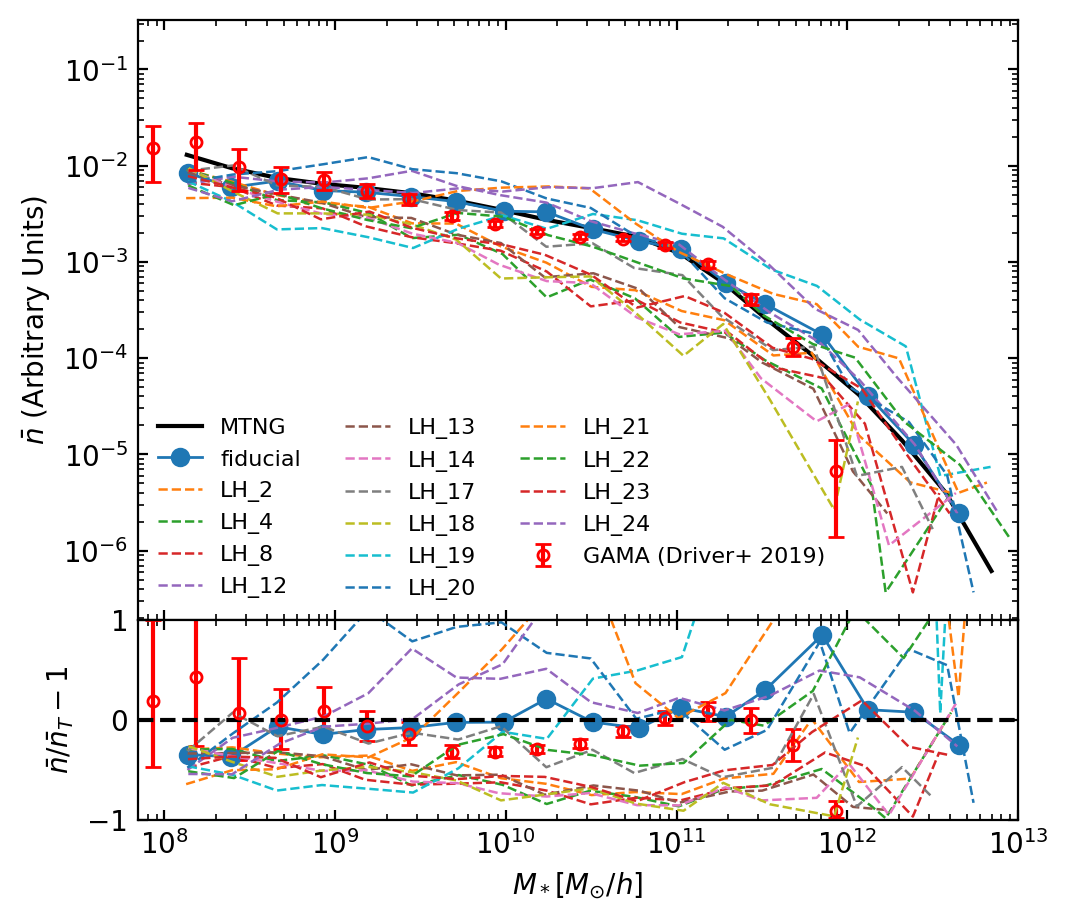

In [437]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB', 'r']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='MTNG', color='k', lw=1.5)

count = 0
for i in range(0, len(name_list)):
    if name_list[i] == 'fiducial':
        ax1.plot(zoom_smf[name_list[i]]['mstar'][0], zoom_smf[name_list[i]]['smf'][0], color='C'+str(i), ls='-', lw=1, label=name_list[i], marker='o')
    else:
        ax1.plot(zoom_smf[name_list[i]]['mstar'][0], zoom_smf[name_list[i]]['smf'][0], color='C'+str(i), ls='--', lw=0.9, label=name_list[i])
    count += 1

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

ax1.legend(loc='lower left', fontsize=8, ncol=3)

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

count=0
for i in range(0,len(name_list)):
    if name_list[i] == 'fiducial':
        ax2.plot(zoom_smf[name_list[i]]['mstar'][0], zoom_smf[name_list[i]]['smf'][0]/np.interp(zoom_smf[name_list[i]]['mstar'][0], smf_total['mstar'], smf_total['smf']) - 1, color='C'+str(count), ls='-', marker='o', lw=1)
    else:
        ax2.plot(zoom_smf[name_list[i]]['mstar'][0], zoom_smf[name_list[i]]['smf'][0]/np.interp(zoom_smf[name_list[i]]['mstar'][0], smf_total['mstar'], smf_total['smf']) - 1, color='C'+str(count), ls='--', lw=0.9)
    count+=1

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

ax2.set_ylabel('$\\bar{n}/\\bar{n}_T - 1$')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')

Text(0.5, 0, '$M_{500c}[M_{\\odot} h^{-1}]$')

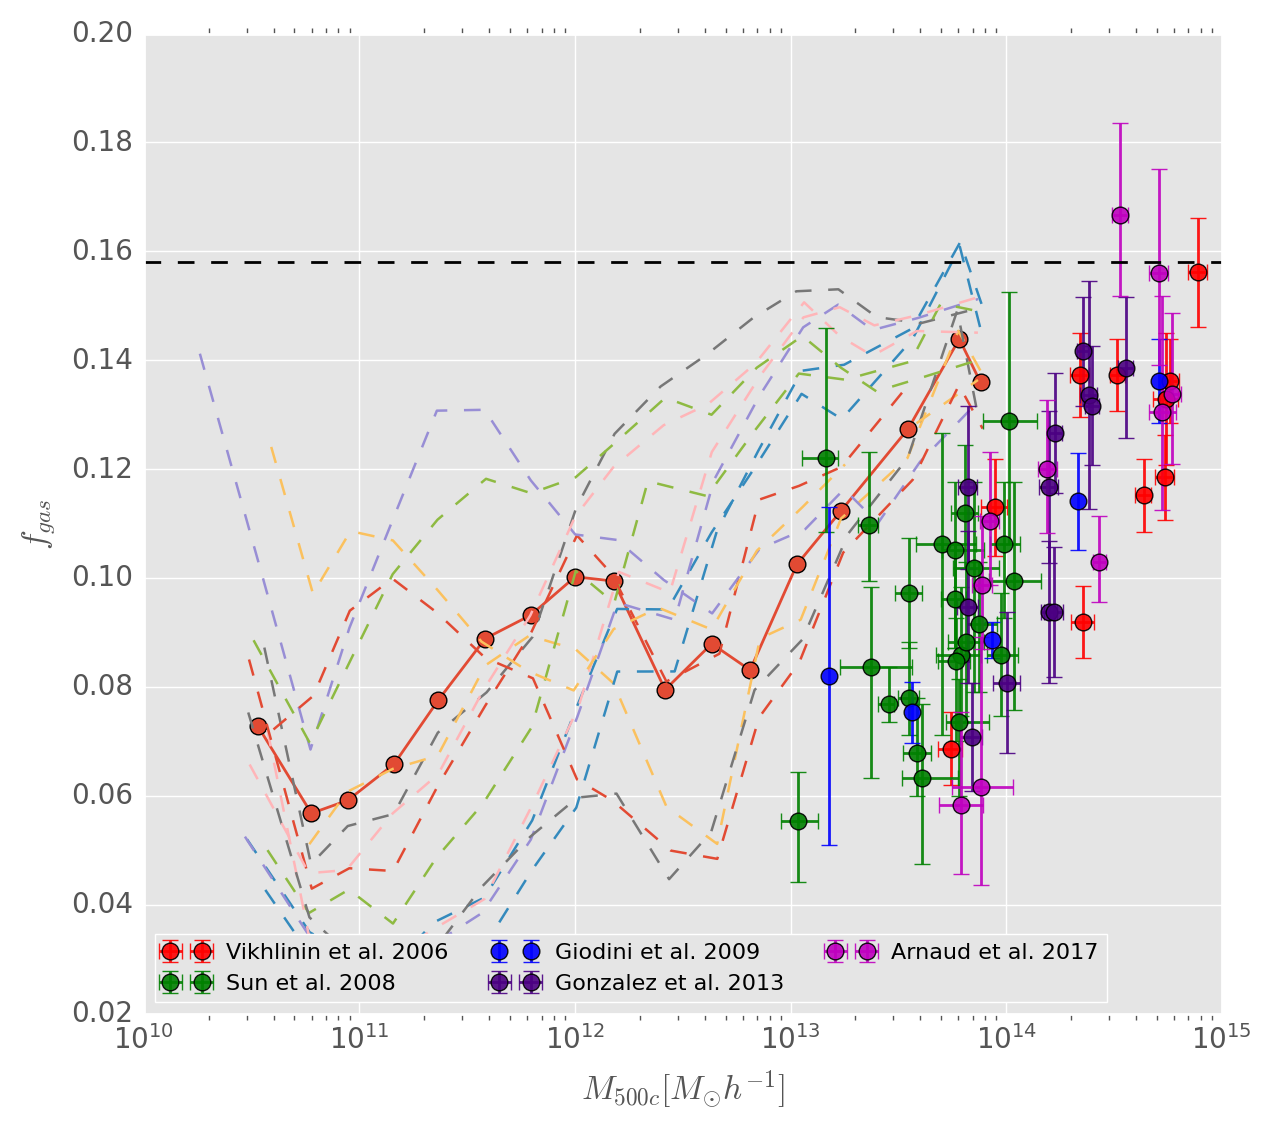

In [64]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('linear')

count = 0
for i in range(0, len(name_list)):
    if name_list[i] == 'fiducial':
        ax.plot(zoom_fgas[name_list[i]]['m500c'][0], zoom_fgas[name_list[i]]['f_gas'][0], color='C'+str(count), ls='-', lw=1,  marker='o')
    else:
        ax.plot(zoom_fgas[name_list[i]]['m500c'][0], zoom_fgas[name_list[i]]['f_gas'][0], color='C'+str(count), ls='--', lw=0.9)
    count += 1

ax.errorbar(m500_V,f_gas_V,yerr=erf_gas_V,xerr=erm500_V,marker='o',c='red',ls='',label='Vikhlinin et al. 2006',alpha=0.9)
ax.errorbar(m500_S,f_gas_S,yerr=(f_gas_Sm,f_gas_Sp),xerr=(m500_Sm,m500_Sp),marker='o',c='g',ls='',label='Sun et al. 2008',alpha=0.9)
ax.errorbar(m500_G,f_gas_G,yerr=erf_gas_G, marker='o',c='blue',ls='',label='Giodini et al. 2009',alpha=0.9)
ax.errorbar(m500,f_gas,yerr=erf_gas,xerr=erm500,marker='o',c='indigo',ls='',label='Gonzalez et al. 2013',alpha=0.9)
ax.errorbar(m500_A,f_gas_A,yerr=(f_gas_Am,f_gas_Ap),xerr=(m500_Am,m500_Ap),marker='o',c='m',ls='',label='Arnaud et al. 2017',alpha=0.9)

ax.legend(loc='lower left', fontsize=8, ncol=3)

ax.axhline(0.158, color='k', ls='--')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500c}[M_{\odot} h^{-1}]$')

In [57]:
plt.style.use('_mpl-gallery')


In [40]:
########################################### baseline  ###########################################################
rebin = False

load_backup = False

cosmo_pars = {
    'omega_matter'  :  0.313,
    'sigma8_cold'   :  0.7482562639166517,
    'omega_baryon'  :  0.0493,
    'ns'            :  0.9649,
    'hubble'        :  0.6727,
    'neutrino_mass' :  93.14*0.00083,
    'w0'            : -1.0,
    'wa'            :  0.0,
    'expfactor'     :  1
    }

baryon_pars ={
    'M_c'           :  14.50053485105879,
    'eta'           : -0.24780202578955512,
    'beta'          : 0.32142878904178573,
    'M1_z0_cen'     : 10.405343976915722,
    'theta_out'     : 0.41894250174563846,
    'theta_inn'     : -0.7024015776841996,
    'M_inn'         : 13.041810858810035
}

pars = {**cosmo_pars, **baryon_pars}
baseline_pars = copy.deepcopy(pars)
cosmo_pars['omega_cdm'] = cosmo_pars['omega_matter'] - cosmo_pars['omega_baryon'] - cosmo_pars['neutrino_mass'] / 93.14 / cosmo_pars['hubble']**2
del cosmo_pars['omega_matter']
cosmo_pars['sigma8'] = cosmo_pars['sigma8_cold']
del cosmo_pars['sigma8_cold']

cosmo = bacco.Cosmology(**cosmo_pars)

#M_c:     68%: +0.62, -0.37 95%: 13.2
#Omega_m: 68%:  +0.025, -0.016 95%: +0.038 -0.045

#X-ray: M_c = 13.5   12.86, 14.3

pars_68_minus = copy.deepcopy(pars)
pars_68_plus = copy.deepcopy(pars)
pars_68_minus['M_c'] -= 0.37
pars_68_plus['M_c'] += 0.62

pars_95_minus = copy.deepcopy(pars)
pars_95_plus = copy.deepcopy(pars)
pars_95_minus['M_c'] = 13.2
pars_95_plus['M_c'] = 15

######################## load DES y3 chains with BACCOemu - baseline



###############################################################################################################


data_dir = '/lscratch/fgmaion/MTNG-resims/'

#WANING: Cosmology dependence of the measurements??? on Universl Baryon fraction
##### Gonzalez
data = np.loadtxt(data_dir+'gas_fractions/Gonzalez_2013.dat',skiprows=1)
f_gas = data[:,1] * 0.6715**(3/2)/(pars['hubble']**(3/2))
erf_gas = data[:,2] * 0.6715**(3/2)/(pars['hubble']**(3/2))
f_star = data[:,3]
erf_star = data[:,4]
m500 = data[:,7]*1e14*0.6715#Hubble factor assumed in the paper
erm500 = data[:,8]*1e14*0.6715
r500 = data[:,9]*0.6715
err500 = data[:,10]*0.6715

r200=virial_concentration_converter(500,r500,200)
m200 = virial_mass_converter(500,m500,r500,200,r200)

####### Vikhlinin
data = np.loadtxt(data_dir+'gas_fractions/Vikhlinin_2006.dat',skiprows=2)
f_gas_V = data[:,14] * 0.72**(3/2)/(pars['hubble']**(3/2))
erf_gas_V = data[:,15] * 0.72**(3/2)/(pars['hubble']**(3/2))
m500_V = data[:,10]*1e14 * 0.72#Hubble factor assumed in the paper
erm500_V = data[:,11]*1e14 * 0.72
r500_V = data[:,0] * 0.72
err500_V = data[:,1] * 0.72

####### Giodini 2009
data = np.loadtxt(data_dir+'gas_fractions/Giodini_2009.dat',skiprows=2)
f_star_G = data[:,1]
erf_star_G = data[:,2]
m500_G = data[:,0] * 0.72#Hubble factor assumed in the paper
f_gas_G = data[:,3] * 0.72**(3/2)/(pars['hubble']**(3/2))
erf_gas_G = data[:,4] * 0.72**(3/2)/(pars['hubble']**(3/2))
f_stargas_G = data[:,5]
erf_stargas_G = data[:,6]

####### Arnaud 2017
data = np.loadtxt(data_dir+'gas_fractions/Arnaud_2007.dat',skiprows=2)

m500_A = data[:,4] *0.7*1e14
m500_Ap = data[:,5] *0.7*1e14
m500_Am = -data[:,6] *0.7*1e14
f_gas_A = data[:,13] * 0.7**(3/2)/(pars['hubble']**(3/2))
f_gas_Ap = data[:,14] * 0.7**(3/2)/(pars['hubble']**(3/2))
f_gas_Am = -data[:,15] * 0.7**(3/2)/(pars['hubble']**(3/2))

##########################################

####### Sun 2008
data = np.loadtxt(data_dir+'gas_fractions/Sun_2008.dat',skiprows=2)

m500_S = data[:,1]*0.73*1e13
m500_Sp = data[:,2]*0.73*1e13
m500_Sm = -data[:,3]*0.73*1e13
f_gas_S = data[:,4]* 0.73**(3/2)/(pars['hubble']**(3/2))
f_gas_Sp = data[:,5]* 0.73**(3/2)/(pars['hubble']**(3/2))
f_gas_Sm = -data[:,6]* 0.73**(3/2)/(pars['hubble']**(3/2))

##########################################

baccom200 = np.logspace(11, np.log10(6e15), 100)
baccoconc200 = cosmo.compute_concentration(baccom200)
baccoconc500 =  virial_concentration_converter(200,baccoconc200,500)
baccom500 = virial_mass_converter(200,baccom200,baccoconc200,500,baccoconc500)


data_ff = np.concatenate( (f_gas_V, f_gas_S, f_gas_G, f_gas, f_gas_A) )
data_m500 = np.concatenate( (m500_V, m500_S, m500_G, m500, m500_A) )
data_m200 = np.exp(np.interp(np.log(data_m500), np.log(baccom500), np.log(baccom200)))
data_std = np.concatenate( (erf_gas_V, 0.5*(f_gas_Sm+f_gas_Sp), erf_gas_G, erf_gas, 0.5*(f_gas_Am+f_gas_Ap)) )

if rebin:
    nbins = 6

    from scipy import stats
    ff_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='mean')
    std_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='std')
    err_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='mean')
    count, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='count')
    err_rebinned = np.sqrt(err_rebinned/count)

    m200_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_m200, bins=nbins, statistic='mean')
    m500_rebinned = np.exp(np.interp(np.log(m200_rebinned), np.log(baccom200), np.log(baccom500)))

    #std_rebinned =  np.sqrt(err_rebinned**2 +std_rebinned**2)

    data_ff = ff_rebinned
    data_m500 = m500_rebinned
    data_m200 = m200_rebinned
    data_std = std_rebinned

if_rebin = '_rebinned' if rebin else ''


bounds = [[12, 15],[-1,1], [0.14,0.45], [0.04,0.06], [0.10,0.5]]

## Check that the 125 shift worked

In [56]:
grid_mtng = bacco.statistics.compute_mesh(pos=mtng.fof['halo_pos'], box=500)
grid_dm_1080 = bacco.statistics.compute_mesh(pos=mtng_dm.fof['halo_pos'], box=500)

Text(0.5, 1.0, 'DM-only')

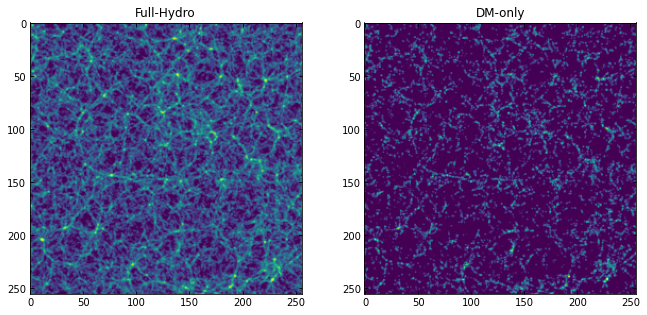

In [57]:
fig, ax = plt.subplots(1,2, figsize=(11,5))

ax[0].imshow(np.log10(1+grid_mtng[0,:,:,0]))
ax[1].imshow(np.log10(1+grid_dm_1080[0,:,:,0]))

ax[0].set_title('Full-Hydro')
ax[1].set_title('DM-only')

### Select the halos

### Define ranges of halo mass

In [11]:
mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

In [12]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

### Plot their Mass and Concentration

In [13]:
m200b = 1e10 * mtng.fof['halo_m200b']
M_T = np.sum(m200b)

presel = np.where(m200b>10**mass_edges[0,0])

m200b = m200b[presel]

In [14]:
halo_vmax = mtng.sub['vmax'][mtng.fof['halo_firstsub']][presel]
r200b = mtng.fof['halo_r200b'][presel]
G_newton = 4.3009172706e-9 #Mpc/M_sun * (km/s)**2
halo_v200 = np.sqrt(G_newton*m200b/r200b)
vmax_v200 = halo_vmax / halo_v200

In [15]:
sel_total = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=None)

0.26914262771606445
0.26929306983947754
1.8209149837493896


In [16]:
ens_sel = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=1, draws=100)

0.2259387969970703
0.22609758377075195
8.325406312942505


### Visualize our selection

Compute their mass-fractions

In [17]:
mfrac = np.zeros(100)

for d in range(100):
    for m in range(mass_edges.shape[0]):
        mfrac[d] += np.sum(m200b[ens_sel['sel'][m][d]]) / M_T

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


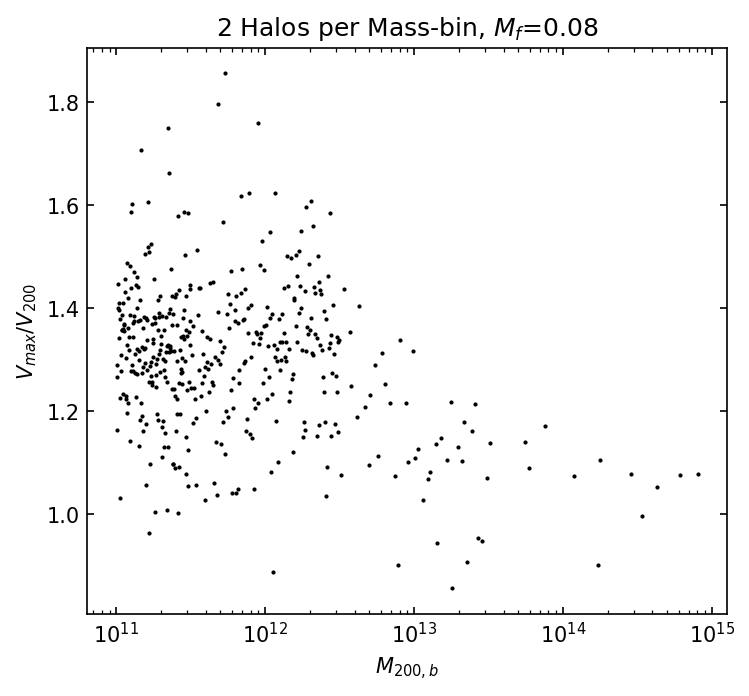

In [18]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True, sharex=True)

ax.set_xscale('log')
#ax[0].set_yscale('log')

ax.set_xlabel('$M_{200,b}$')
ax.set_ylabel('$V_{max}/V_{200}$')

ax.set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac)))

for m in range(mass_edges.shape[0]):
    ax.plot(m200b[ens_sel['sel'][m][0]], vmax_v200[ens_sel['sel'][m][0]], marker='o', ls='', color='k', ms=1)

ax.legend(loc='upper left')

# ax[1,0].set_xscale('log')
# #ax[0].set_yscale('log')

# ax[1,0].set_xlabel('$M_{200,b}$')
# ax[1,0].set_ylabel('$V_{max}/V_{200}$')

# ax[1,0].set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['2'])))

# for m in range(mass_edges.shape[0]):
#     ax[1,0].plot(m200b[ens_sel_vmax['2']['sel'][m][0]], vmax_v200[ens_sel_vmax['2']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,0].legend(loc='upper left')

# ax[1,1].set_xscale('log')
# #ax[1].set_yscale('log')

# ax[1,1].set_xlabel('$M_{200,b}$')

# ax[1,1].set_title('4 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['4'])))

# cmap = matplotlib.cm.get_cmap('viridis')

# for m in range(mass_edges.shape[0]):
#     ax[1,1].plot(m200b[ens_sel_vmax['4']['sel'][m][0]], vmax_v200[ens_sel_vmax['4']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,1].legend(loc='upper left')

### SMF for these selections

In [73]:
nbins=30

In [74]:
ens_smf = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_smf(sel_mask=ens_sel, nbins=nbins, mhalo_edges=mass_edges, draws=100)

for i in range(100):
    ens_smf[i] = temp['smf'][i]
    ens_mstar[i] = temp['mstar'][i]
    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_smf[i][np.where(np.isnan(ens_mstar[i]))] = 0

2024-08-05 15:46:08,862 bacco.sims : Reading 98233510 items for GroupNsubs
2024-08-05 15:46:12,349 bacco.sims : Reading 90246895 items for SubhaloMassType
/lscratch/fgmaion/MTNG-resims/src/utils.py:211: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] = mstar_mean[d] / counts[d]


In [75]:
mean_smf   = np.sum(ens_smf, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_smf    = np.sqrt( np.sum(ens_smf**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_smf, axis=0) / np.sum(weights, axis=0) )**2 )

In [76]:
smf_total = hydro_split.total_smf(nbins=nbins)

In [77]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

In [78]:
GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = 10**GAMA[:,0] / 0.7**2
GAMA_corr[:,1] = 10**GAMA[:,1] * 0.7**3

GAMA_corr[:,2] = 10**GAMA[:,1] - 10**(GAMA[:,1] - GAMA[:,2])
GAMA_corr[:,3] = 10**(GAMA[:,1] + GAMA[:,2]) - 10**GAMA[:,1]

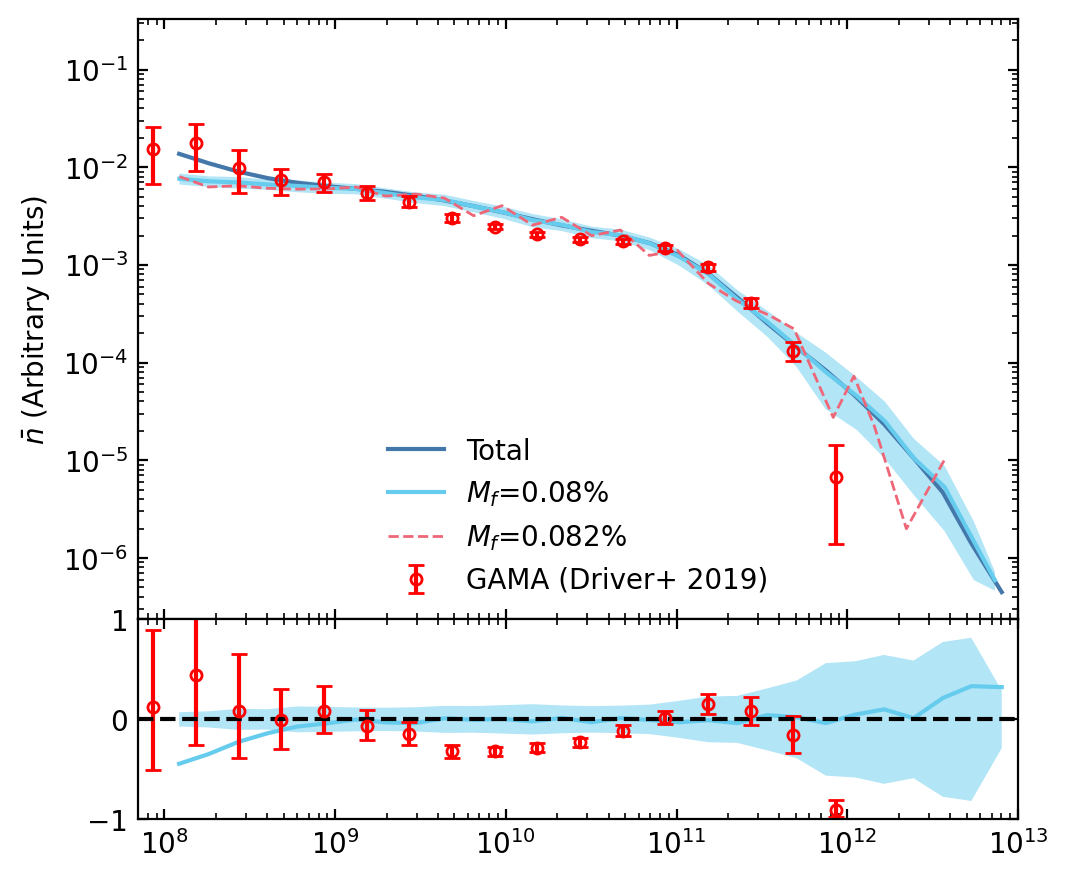

In [79]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='Total', color=colors[0])
ax1.plot(mean_mstar, mean_smf, color=colors[1], label='$M_f$={:.2f}%'.format(100*np.mean(mfrac))) 

ax1.fill_between(mean_mstar, mean_smf-err_smf, mean_smf+err_smf, color=colors[1], alpha=0.5, edgecolor=None)

# for i in range(25,30):
#   ax1.plot(ens_mstar[i], ens_smf[i])

ax1.plot(ens_mstar[28][:-2], ens_smf[28][:-2], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[28]), lw=1)
# ax1.plot(ens_mstar[8], ens_smf[8], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[8]), lw=1)
# ax1.plot(ens_mstar[87], ens_smf[87], color=colors[2], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[87]), lw=1)
# ax1.plot(ens_mstar[92], ens_smf[92], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[92]), lw=1)

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar, mean_smf)/smf_total['smf'] - 1, color=colors[1])

ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], color=colors[1], alpha=0.5, edgecolor=None)

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

# ax2.set_ylim(-0.5,0.5)

# #ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
# #ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

# ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')




## What about gas-fraction

In [29]:
m500_bins = np.arange(10, 15, 0.1)
m500_edges = np.array(list(zip(m500_bins[:-1], m500_bins[1:])))

In [30]:
nbins=11

ens_fgas = np.zeros((100, nbins-1))
ens_m500 = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, nbins=nbins, draws=100)

for i in range(100):
    ens_fgas[i] = temp['f_gas'][i]
    ens_m500[i] = temp['m500c'][i]

    weights[i][np.where(np.isnan(ens_m500[i]))] = 0

    ens_fgas[i][np.where(np.isnan(ens_m500[i]))] = 0
    ens_m500[i][np.where(np.isnan(ens_m500[i]))] = 0

2024-08-02 14:43:17,534 bacco.sims : Reading 98233510 items for Group_M_Crit500
/lscratch/fgmaion/MTNG-resims/src/utils.py:274: RuntimeWarning: invalid value encountered in divide
  fgas[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:275: RuntimeWarning: invalid value encountered in divide
  m500c_mean[d] /= counts[d]


In [31]:
mean_fgas   = np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0)
mean_m500 = np.sum(ens_m500, axis=0) / np.sum(weights, axis=0)
err_fgas    = np.sqrt( np.sum(ens_fgas**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0) )**2 )

In [32]:
fgas_total = hydro_split.total_gas_frac(m500_edges=m500_edges, mass_edges=mass_edges)

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

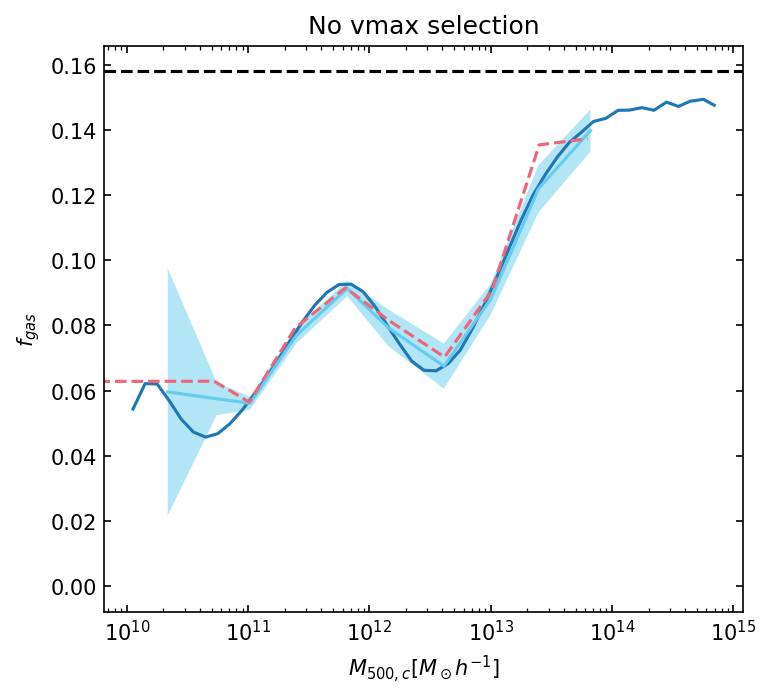

In [33]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500, mean_fgas, color=colors[1])
# ax.plot(ens_m500[3], ens_fgas[3], color=colors[2], ls='--')
ax.plot(ens_m500[28], ens_fgas[28], color=colors[4], ls='--')

ax.fill_between(mean_m500, mean_fgas-err_fgas, mean_fgas+err_fgas, color=colors[1], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('No vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

In [34]:
sfr_mstar = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=20)

2024-08-02 14:44:22,327 bacco.sims : Reading 90246895 items for SubhaloSFR
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: invalid value encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: divide by zero encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:337: RuntimeWarning: invalid value encountered in divide
  sSFR_mean[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:338: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] /= counts[d]


In [35]:
nbins=30

ens_sSFR = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))


temp = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=nbins)

for i in range(100):
    ens_sSFR[i] = temp['sSFR'][i]
    ens_mstar[i] = temp['mstar'][i]

    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0

    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_mstar[i]))] = 0
    

In [36]:
mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )

/tmp/ipykernel_92207/45664116.py:1: RuntimeWarning: invalid value encountered in divide
  mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_92207/45664116.py:2: RuntimeWarning: invalid value encountered in divide
  mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_92207/45664116.py:3: RuntimeWarning: invalid value encountered in divide
  err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )


In [37]:
sSFR_total = hydro_split.total_SFR(nbins=nbins)

/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: divide by zero encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: invalid value encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar


In [38]:
mstar_bauer = np.array([9, 9.5, 10, 10.5, 11])
ssfr_bauer = np.array([-0.7, -0.8,-0.81,-1,-1.3])
err_bauer_low = np.ones(5) * (10**(ssfr_bauer) - 10**(ssfr_bauer-0.5) )
err_bauer_high = np.ones(5) * (10**(ssfr_bauer+0.5) - 10**(ssfr_bauer) )

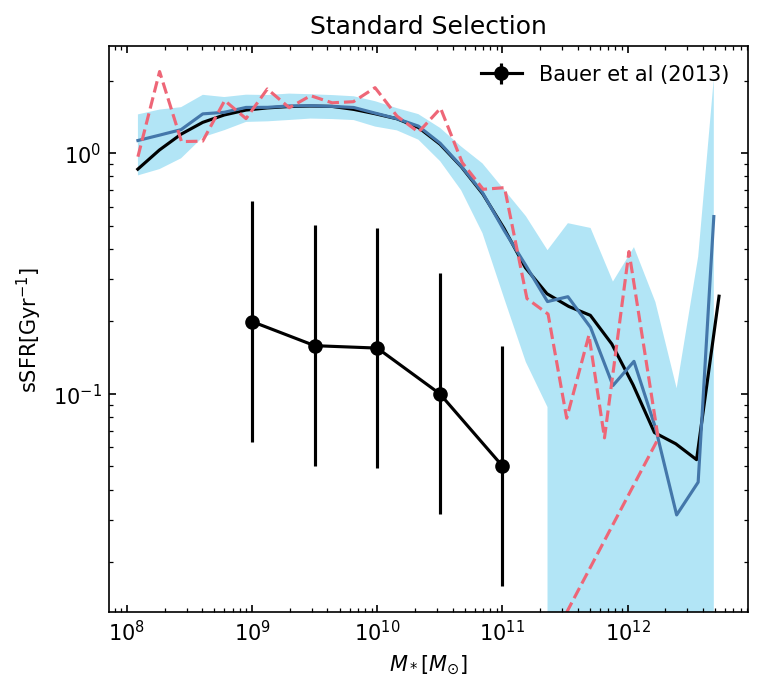

In [39]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('sSFR[Gyr$^{-1}$]')
ax.set_xlabel('$M_*[M_{\\odot}]$')

ax.set_title('Standard Selection')

ax.plot(sSFR_total['mstar'][:-1], sSFR_total['sSFR'][:-1], color='k')
ax.plot(mean_mstar, mean_sSFR, color=colors[0])
ax.plot(ens_mstar[28][:-3], ens_sSFR[28][:-3], color=colors[4], ls='--')
# for i in range(20,25):
#     ax.plot(ens_mstar[i], ens_sSFR[i])

ax.fill_between(mean_mstar, mean_sSFR-err_sSFR, mean_sSFR+err_sSFR, color=colors[1], alpha=0.5, edgecolor=None)

ax.errorbar(10**(mstar_bauer), 10**(ssfr_bauer), [err_bauer_low, err_bauer_high],  marker='o', label='Bauer et al (2013)', color='k')

ax.legend()

### Cross-match the selected halos

In [40]:
# final_sel = np.zeros(mass_edges.shape[0], dtype=int)
# for i in range(mass_edges.shape[0]):
#     final_sel[i] = ens_sel['sel'][i][28][0]

In [58]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [25]:
from scipy.spatial import KDTree

In [59]:
X1 = mtng.fof['halo_pos'][final_sel]
X2 = mtng_dm.fof['halo_pos']

kdt = KDTree(X2, boxsize=500)
dist, ind = kdt.query(X1, k=100)

ind[np.where(dist==np.inf)] = -1

In [60]:
M1 = 1e10 * mtng.fof['halo_m200b'][final_sel]
M2 = 1e10 * mtng_dm.fof['halo_m200b'][ind]

pos1 = mtng.fof['halo_pos'][final_sel].T
pos2 = np.transpose(mtng_dm.fof['halo_pos'][ind], (2,0,1))

vmax_1 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]]
vmax_2 = mtng_dm.sub['vmax'][mtng_dm.fof['halo_firstsub'][ind]]

2024-08-05 10:34:09,190 bacco.sims : Reading 98233510 items for Group_M_Mean200
2024-08-05 10:34:10,416 bacco.sims : Reading 1780958 items for Group_M_Mean200
2024-08-05 10:34:10,803 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-08-05 10:34:11,834 bacco.sims : Reading 98233510 items for halo_firstsub
2024-08-05 10:34:25,197 bacco.sims : Reading 2219376 items for SubhaloVmax
2024-08-05 10:34:25,287 bacco.sims : Reading 1780958 items for halo_firstsub


In [61]:
def metric(m1,m2,x1,x2,v1,v2,a,b,c):

    d_x = np.sqrt(np.sum((x1[...,np.newaxis]-x2)**2, axis=0))
    d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    d_v = np.abs(v1[...,np.newaxis]-v2)

    return d_x**a + d_m**b + d_v**c


In [62]:
d = metric(M1,M2,pos1,pos2,vmax_1,vmax_2,2,0.3,0.3)

/tmp/ipykernel_123923/1876228836.py:4: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))


In [63]:
xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))

for i in range(len(M1)):
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

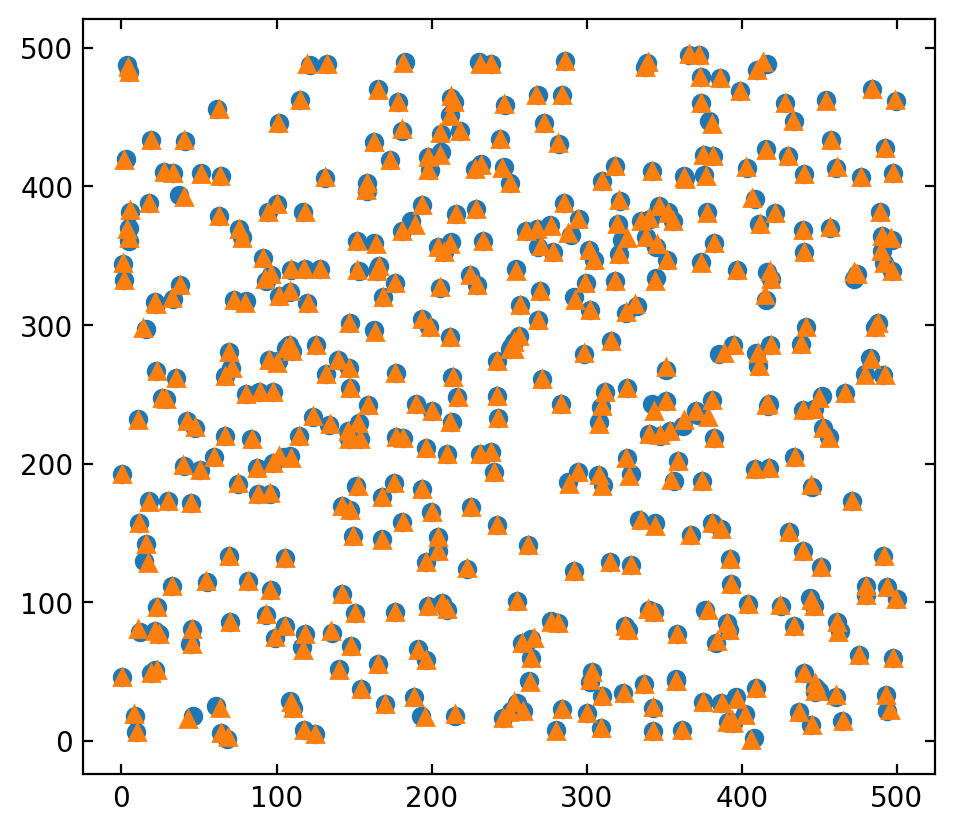

In [64]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.plot(mtng.fof['halo_pos'][final_sel][:,1], mtng.fof['halo_pos'][final_sel][:,2], marker='o', ls='')
ax.plot(mtng_dm.fof['halo_pos'][xmatch][:,1], mtng_dm.fof['halo_pos'][xmatch][:,2], marker='^', ls='')

Exception ignored in: <function Simulation.__del__ at 0x2b1bd26010d0>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 580, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 10629, in cleanup
    clean_lazy(self, attributes)
  File "/lscratch/fgmaion/baccogit/bacco/utils.py", line 4112, in clean_lazy
    delattr(obj, t)
AttributeError: dm


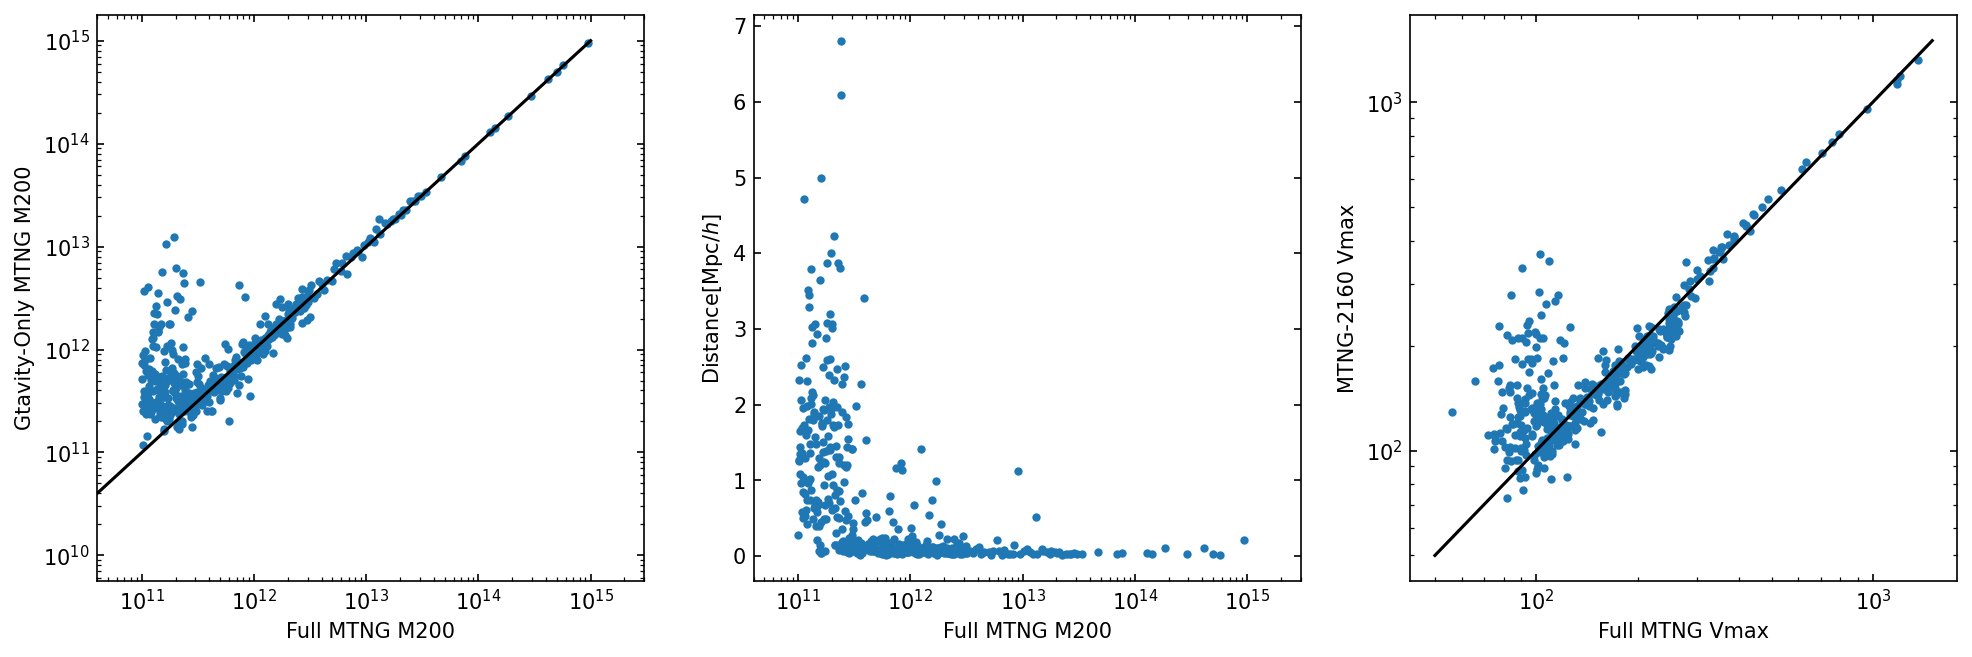

In [65]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ratio = np.zeros(xmatch.shape)
for i in range(xmatch.shape[0]):
    ratio[i] = mtng.fof['halo_m200b'][final_sel][i] / mtng_dm.fof['halo_m200b'][xmatch[i]]
    ax[0].plot(1e10*mtng.fof['halo_m200b'][final_sel][i], 1e10*mtng_dm.fof['halo_m200b'][xmatch[i]], marker='o', color='C0', ms=3)

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Gtavity-Only MTNG M200')

ax[0].plot(np.logspace(10,15,10), np.logspace(10,15,10), color='k')

ax[0].set_xlim(4e10,3e15)

#

ax[1].set_xscale('log')

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[$Mpc$/h]$')

for i in range(dmatch.shape[0]):
    ax[1].plot(1e10*mtng.fof['halo_m200b'][final_sel][i], dmatch[i], marker='o', color='C0', ms=3)

ax[1].set_xlim(4e10,3e15)

#

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('MTNG-2160 Vmax')

for i in range(dmatch.shape[0]):
    ax[2].plot(mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel][i]], mtng_dm.sub['vmax'][mtng_dm.fof['halo_firstsub'][xmatch[i]]], marker='o', color='C0', ms=3)

ax[2].plot(np.linspace(50,1500,100), np.linspace(50,1500,100), color='k')

#ax[2].set_xlim(4e10,3e15)


In [32]:
halo_neigh = {}
grid_neigh = {}
i=0
while(ind[283,i]!=-1):
    halo_neigh[i] = mtng_dm.get_halo_particles(ihalo=ind[283,i], relative=False)
    grid_neigh[i] = bacco.statistics.compute_mesh(pos=halo_neigh[i] - np.mean(halo_neigh[0], axis=0) + 1.5, box=3, ngrid=128)
    i+=1

2024-08-05 10:20:55,977 bacco.sims : Reading 11273943 items for Group/GroupLen
2024-08-05 10:20:57,027 bacco.sims : Reading 11273943 items for GroupLen
2024-08-05 10:20:57,596 bacco.sims : Read data for 172227489/10077696000 particles...


/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-2160-A/snapdir_265/snapshot_265.0.hdf5


2024-08-05 10:21:14,708 bacco.sims : Read data for 172227489/10077696000 particles...
2024-08-05 10:21:14,721 bacco.sims : Read data for 168817832/10077696000 particles...
2024-08-05 10:21:30,997 bacco.sims : Read data for 168817832/10077696000 particles...
2024-08-05 10:21:31,002 bacco.sims : Read data for 167943350/10077696000 particles...


KeyboardInterrupt: 

In [267]:
mtng_dm.fof['halo_m200b'][xmatch[283]]

17.648134

In [268]:
mtng.fof['halo_m200b'][final_sel[283]]

82.8786

In [269]:
halo_pos = mtng.fof['halo_pos'] - np.mean(halo_neigh[0], axis=0) + 1.5

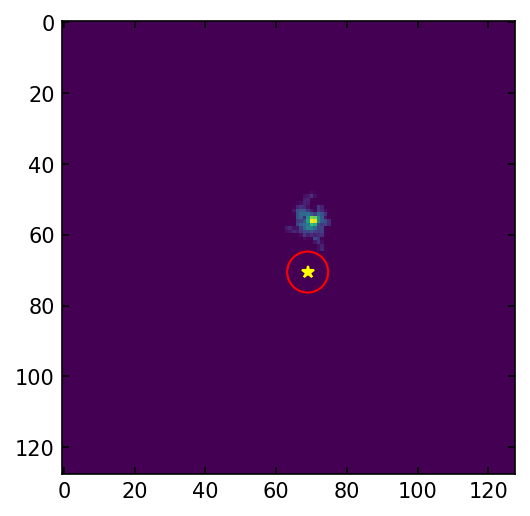

In [273]:
fig, ax = plt.subplots(dpi=150)

ax.imshow(np.log10(1+np.sum(grid_neigh[8][0,:,:,:],axis=0)))

ax.plot(halo_pos[final_sel[283],2]*128/3, halo_pos[final_sel[283],1]*128/3, marker='*', color='yellow')
circle1 = plt.Circle((halo_pos[final_sel[283],2]*128/3, halo_pos[final_sel[283],1]*128/3), mtng.fof['halo_r200b'][final_sel][283]*128/5, color='r', fill=False)

ax.add_patch(circle1)


In [994]:
mtng_dm.fof['halo_m200b'][xmatch[219]]

294.9152

In [996]:
mtng.fof['halo_m200b'][sel[1]]

8155.4595

In [66]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080_dm_halo_sel_1pmbin.txt", 'w') as f:
    for i in range(len(xmatch)):
        if i==len(xmatch)-1:
            f.write(str(xmatch[i]))
        else:
            f.write(str(xmatch[i])+'\n')

# with open("/lscratch/fgmaion/MTNG-resims/halo_selections/hydro_halo_sel_1pmbin.txt", 'w') as f:
#     for i in range(len(final_sel)):
#         if i==len(final_sel)-1:
#             f.write(str(final_sel[i]))
#         else:
#             f.write(str(final_sel[i])+'\n')

In [67]:
#np.save("/cosmos_storage/data_sharing/resims_info/hydro_properties_halo_sel_1pmbin.npy", [{'pos':mtng.fof['halo_pos'][final_sel], 'm200b':mtng.fof['halo_m200b'][final_sel]}] )
np.save("/cosmos_storage/data_sharing/resims_info/1080_dm_properties_halo_sel_1pmbin.npy", [{'pos':mtng_dm.fof['halo_pos'][xmatch], 'm200b':mtng_dm.fof['halo_m200b'][xmatch]}] )

In [69]:
dm_pos = np.load("/cosmos_storage/data_sharing/resims_info/1080_dm_properties_halo_sel_1pmbin.npy", allow_pickle=True)[0]

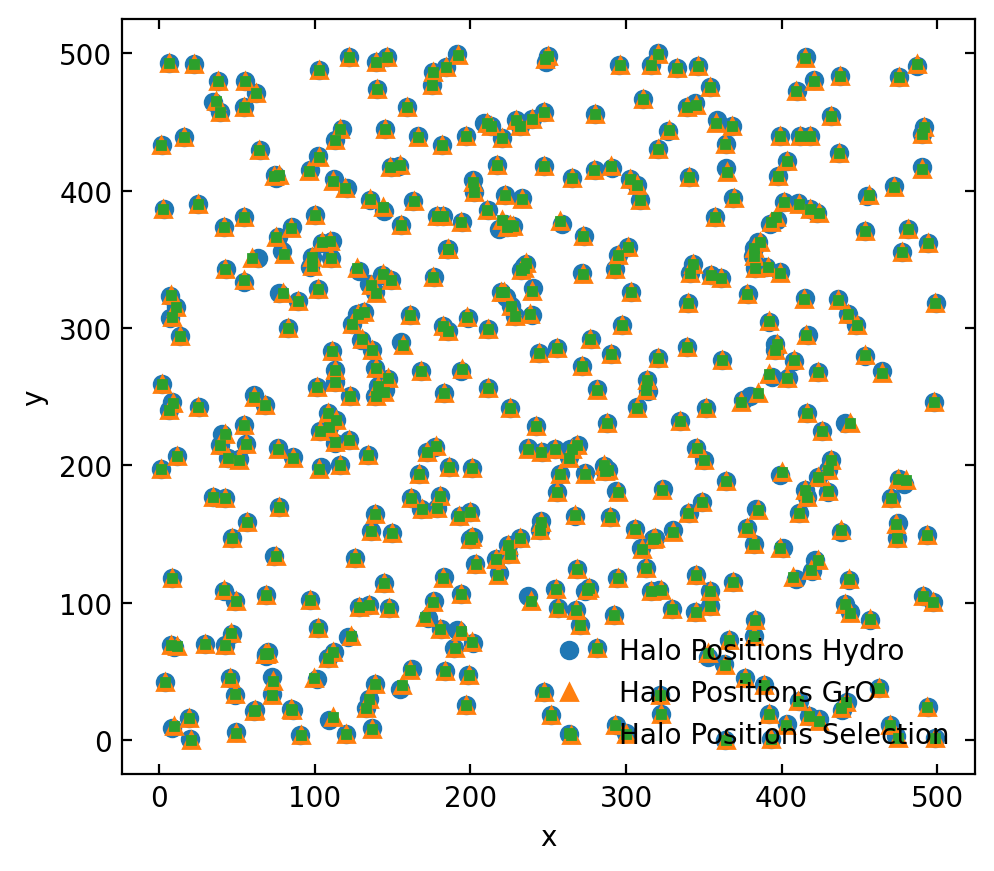

In [70]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.plot(mtng.fof['halo_pos'][final_sel][:,0], mtng.fof['halo_pos'][final_sel][:,1], marker='o', ls='', label='Halo Positions Hydro')
ax.plot(mtng_dm.fof['halo_pos'][xmatch][:,0], mtng_dm.fof['halo_pos'][xmatch][:,1], marker='^', ls='', label='Halo Positions GrO')
ax.plot(dm_pos['pos'][:,0], dm_pos['pos'][:,1], marker='s', ls='', ms=3, label='Halo Positions Selection')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.legend()